<a href="https://colab.research.google.com/github/faddeltnrlifu/Analysing-Pharma-Sales-Data/blob/main/AnalysingPharmaceuticalSalesData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1) (2).json


{'kaggle (1) (2).json': b'{"username":"faddeltnrlipu","key":"b4236a5f2712166ee82eaa2fe85082bd"}'}

In [33]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [34]:
!kaggle datasets download -d milanzdravkovic/pharma-sales-data
!unzip pharma-sales-data.zip

Dataset URL: https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
pharma-sales-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  pharma-sales-data.zip
replace salesdaily.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: salesdaily.csv          
  inflating: saleshourly.csv         
  inflating: salesmonthly.csv        
  inflating: salesweekly.csv         


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Memuat dataset ke DataFrame
df = pd.read_csv('salesdaily.csv')
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [36]:
# Nama kolom & informasi tipe data
print('Kolom:', df.columns.tolist())
print('Ukuran (baris, kolom):', df.shape)
df.info()

Kolom: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']
Ukuran (baris, kolom): (2106, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [37]:
# Ringkasan statistik kolom numerik
df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


In [38]:
df['datum'] = pd.to_datetime(df['datum'], format='%m/%d/%Y')
print('Tipe kolom datum:', df['datum'].dtype)

Tipe kolom datum: datetime64[ns]


In [39]:
# Daftar kolom kategori ATC
kategori_atc = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Total penjualan tiap kategori, diurutkan dari terbesar
total_per_kategori = df[kategori_atc].sum().sort_values(ascending=False)
print(total_per_kategori)

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


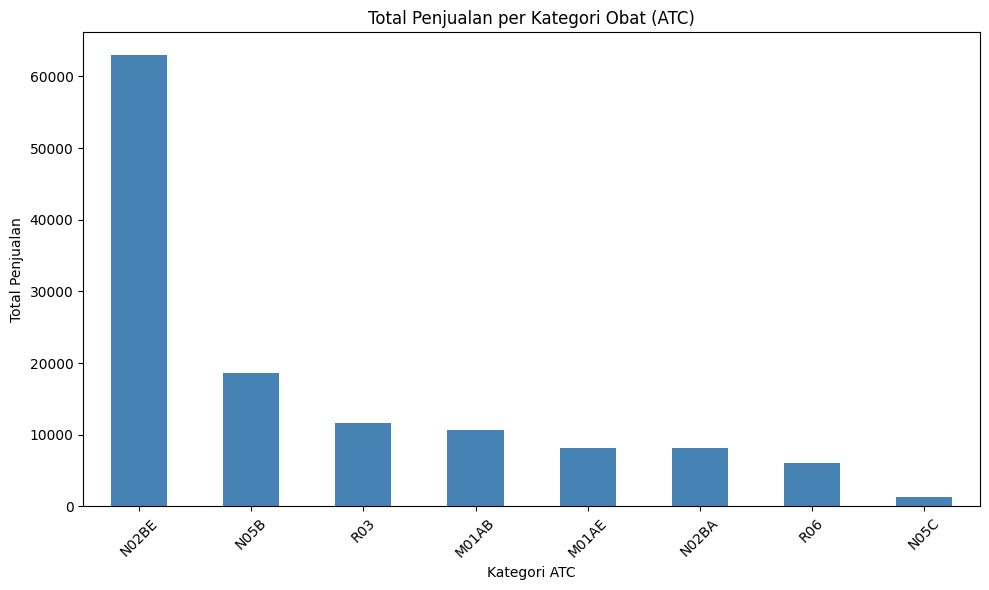

In [40]:
# Visualisasi: bar chart total penjualan per kategori
plt.figure(figsize=(10, 6))
total_per_kategori.plot(kind='bar', color='steelblue')
plt.title('Total Penjualan per Kategori Obat (ATC)')
plt.xlabel('Kategori ATC')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
brand_tertinggi = total_per_kategori.idxmax()
nilai_tertinggi = total_per_kategori.max()
print(f'Kategori dengan penjualan tertinggi: {brand_tertinggi}')
print(f'Total penjualan: {nilai_tertinggi:.2f}')

Kategori dengan penjualan tertinggi: N02BE
Total penjualan: 63005.40


In [42]:
def top3_obat(tahun, bulan):
    data_periode = df[(df['Year'] == tahun) & (df['Month'] == bulan)]
    total = data_periode[kategori_atc].sum()
    return total.sort_values(ascending=False).head(3)

print('=== Januari 2015 ===')
print(top3_obat(2015, 1))
print('\n=== Juli 2016 ===')
print(top3_obat(2016, 7))
print('\n=== September 2017 ===')
print(top3_obat(2017, 9))

=== Januari 2015 ===
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

=== Juli 2016 ===
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64

=== September 2017 ===
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


In [43]:
data_2017 = df[df['Year'] == 2017]
total_2017 = data_2017[kategori_atc].sum().sort_values(ascending=False)
print('Total penjualan tiap kategori di 2017:')
print(total_2017)
print(f'\nObat paling laku di 2017: {total_2017.idxmax()} ({total_2017.max():.2f})')

Total penjualan tiap kategori di 2017:
N02BE    9258.804833
N05B     2555.541667
R03      1893.614583
M01AB    1846.617083
M01AE    1387.298333
N02BA    1288.295833
R06       988.860000
N05C      180.333333
dtype: float64

Obat paling laku di 2017: N02BE (9258.80)


In [44]:
rata_harian = df[kategori_atc].mean().sort_values(ascending=False)
print('Rata-rata penjualan harian tiap kategori:')
print(rata_harian)
print(f'\nRata-rata harian tertinggi: {rata_harian.idxmax()} ({rata_harian.max():.2f})')

Rata-rata penjualan harian tiap kategori:
N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64

Rata-rata harian tertinggi: N02BE (29.92)


In [45]:
r03_per_bulan = df.groupby('Month')['R03'].sum()
print('Total penjualan R03 per bulan (semua tahun digabung):')
print(r03_per_bulan)

Total penjualan R03 per bulan (semua tahun digabung):
Month
1     1264.656250
2     1165.583333
3     1170.000000
4     1038.875000
5      931.291667
6      783.000000
7      550.000000
8      577.000000
9      792.416667
10    1175.000000
11     934.000000
12    1227.000000
Name: R03, dtype: float64


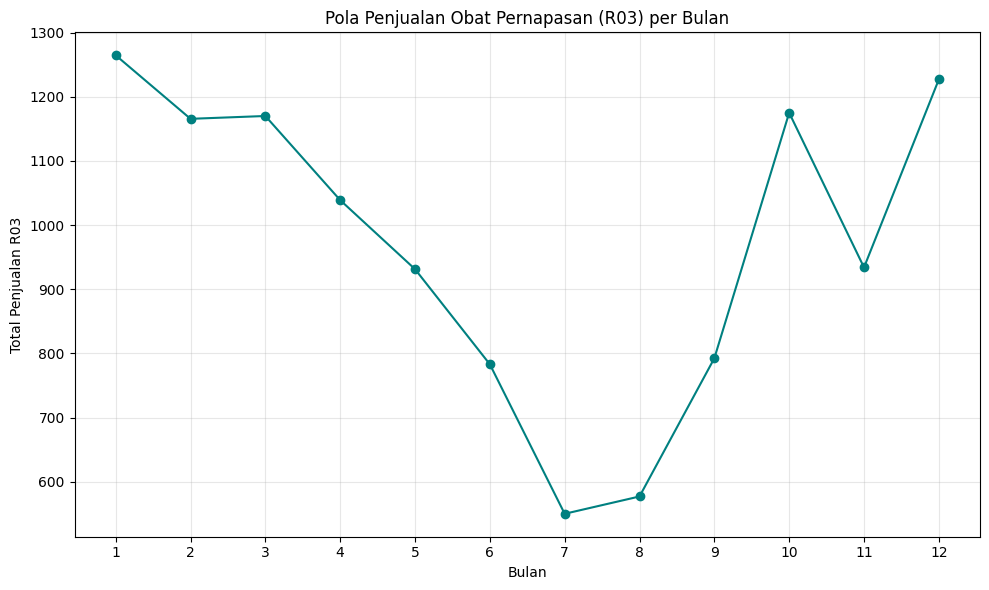

In [46]:
# Visualisasi: pola R03 sepanjang bulan
plt.figure(figsize=(10, 6))
r03_per_bulan.plot(kind='line', marker='o', color='teal')
plt.title('Pola Penjualan Obat Pernapasan (R03) per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan R03')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()